In [8]:
import torch
import torch.nn as nn

In [9]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        skip = self.skip(x)
        out = out + skip
        out = self.relu(out)
        return out

In [10]:
class ForecastNet(nn.Module):
    def __init__(self, in_channels):
        super(ForecastNet, self).__init__()

        self.conv_1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1)
        self.bn_1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.conv_2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(128)

        self.conv_3 = nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.bn_3 = nn.BatchNorm2d(64)

        self.conv_4 = nn.Conv2d(64, in_channels, kernel_size=3, stride=1, padding=1)
        self.bn_4 = nn.BatchNorm2d(in_channels)


    def forward(self, x):
        out = self.conv_1(x)
        out = self.bn_1(out)
        out = self.relu(out)

        out = self.conv_2(out)
        out = self.bn_2(out)
        out = self.relu(out)

        out = self.conv_3(out)
        out = self.bn_3(out)
        out = self.relu(out)

        out = self.conv_4(out)
        out = self.bn_4(out)
        return out
    

In [11]:
from models.vqvae import VQVAE
from dataset.vae_dataset import VAEDataset

vae = VQVAE.load_from_checkpoint("logs/vqvae_5channel/version_46/checkpoints/epoch=201-step=4751.ckpt", in_channels=5)
ds = VAEDataset(path="train.memmap", channels=5, img_res=(128, 64))

model = ForecastNet(8).to("cuda")

In [12]:
critertion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
for _ in range(10):
    loss_sum = 0

    for i in range(100):
        x_1 = torch.Tensor(ds[i]).to("cuda")
        x_2 = torch.Tensor(ds[i+1]).to("cuda")

        # x = x.unsqueeze(0)
        # _, latens, _ = vae(x)

        x_1 = x_1.unsqueeze(0)
        _, latens_1, _ = vae(x_1)

        x_2 = x_2.unsqueeze(0)
        _, latens_2, _ = vae(x_2)
        
        pred = model(latens_1)
        loss = critertion(pred, latens_2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
    
    print(loss_sum)
    

38.25564742088318
23.72236305475235
16.41118983924389
11.523904703557491
8.197950229048729
5.956215146929026
4.47330480068922
3.5108416192233562
2.9108503479510546
2.6288968715816736


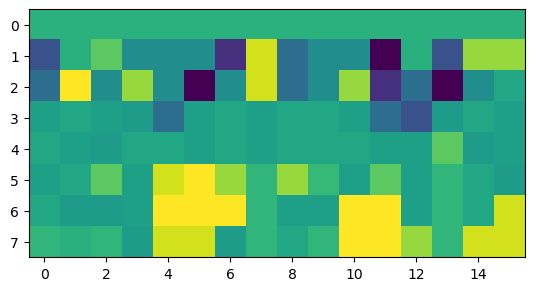

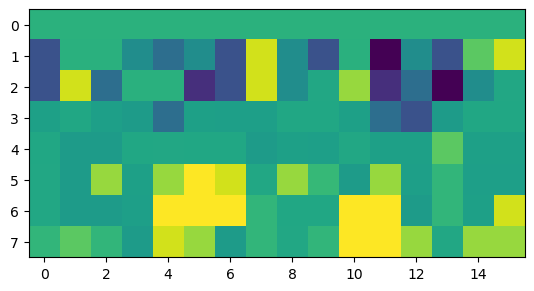

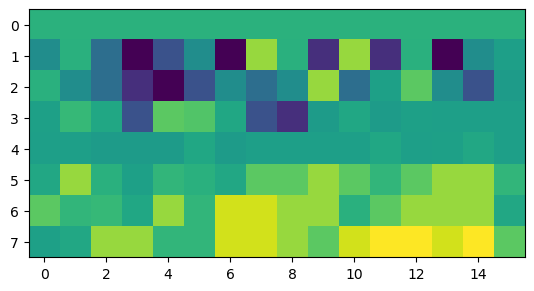

In [34]:
x_1 = torch.Tensor(ds[0]).to("cuda")
x_2 = torch.Tensor(ds[1]).to("cuda")

x_1 = x_1.unsqueeze(0)
_, latens_1, _ = vae(x_1)

x_2 = x_2.unsqueeze(0)
_, latens_2, _ = vae(x_2)

pred = model(latens_1)

for i in range(100):
    pred = model(pred)

pred, _, _= vae.quantize(pred)

import matplotlib.pyplot as plt

plt.imshow(latens_1[0, 0].detach().cpu().numpy().T)
plt.show()
plt.imshow(latens_2[0, 0].detach().cpu().numpy().T)
plt.show()
plt.imshow(pred[0, 0].detach().cpu().numpy().T)
plt.show()

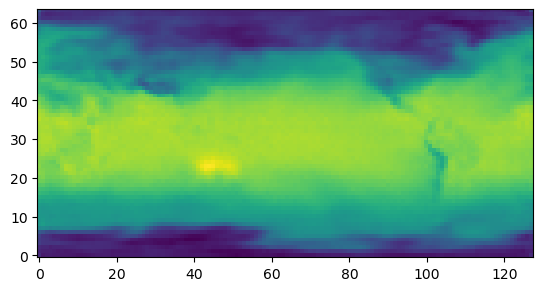

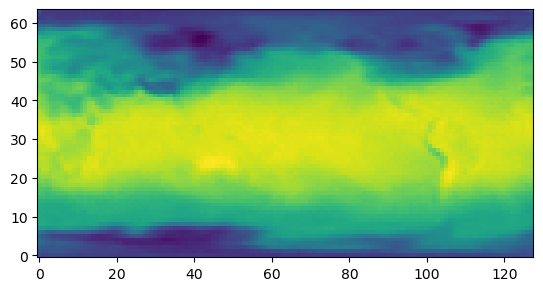

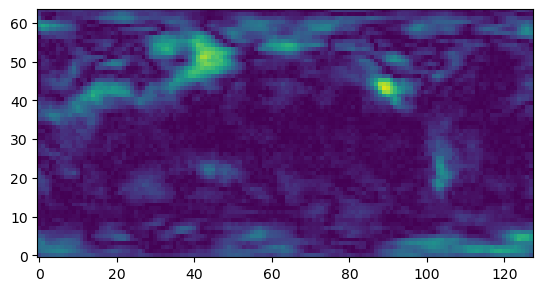

In [38]:
forecast = vae.decode(pred)

x_10 = torch.Tensor(ds[100]).to("cuda")


x_10 = x_10.unsqueeze(0)
_, latens_10, _ = vae(x_10)

real = vae.decode(latens_10)

diff = torch.abs(forecast - real)

plt.imshow(forecast[0][3].detach().cpu().numpy().T, origin="lower")
plt.show()
plt.imshow(real[0][3].detach().cpu().numpy().T, origin="lower")
plt.show()
plt.imshow(diff[0][3].detach().cpu().numpy().T, origin="lower", vmin=0, vmax=1)
